In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Sugeneruojame pardavimų duomenis
np.random.seed(42)
data = pd.DataFrame({
    "Pardavimai": np.random.normal(loc=5000, scale=1200, size=1000),  
    "Klientų_amžius": np.random.randint(18, 70, size=1000),  
    "Parduotuvės_reitingas": np.random.uniform(1, 5, size=1000),  
    "Produktų_kategorija": np.random.choice(["Elektronika", "Drabužiai", "Bakalėja", "Baldai"], size=1000, p=[0.4, 0.3, 0.2, 0.1]),
})

In [3]:
data.head()

,Pardavimai,Klientų_amžius,Parduotuvės_reitingas,Produktų_kategorija
0,5596.056984,61,3.216906,Elektronika
1,4834.082839,66,1.020918,Bakalėja
2,5777.226246,57,4.043963,Elektronika
3,6827.635828,28,1.141245,Drabužiai
4,4719.015950,20,3.982935,Drabužiai


In [4]:
data.describe()

,Pardavimai,Klientų_amžius,Parduotuvės_reitingas
count,1000.000000,1000.000000,1000.000000
mean,5023.198467,43.080000,2.988864
std,1175.059126,15.047526,1.157172
min,1110.479192,18.000000,1.000539
25%,4222.891633,30.000000,2.039257
50%,5030.360735,42.000000,2.976053
75%,5777.532651,56.000000,4.014246
max,9623.277789,69.000000,4.993390


In [5]:
vidurkis = data["Pardavimai"].mean()
mediana = data["Pardavimai"].median()
moda = data["Pardavimai"].mode()[0]

print(f"Pardavimų vidurkis: {vidurkis:.2f}")
print(f"Pardavimų mediana: {mediana:.2f}")
print(f"Pardavimų moda: {moda:.2f}")

Pardavimų vidurkis: 5023.20
Pardavimų mediana: 5030.36
Pardavimų moda: 1110.48


In [6]:
std = data["Pardavimai"].std()
variance = data["Pardavimai"].var()
range = data["Pardavimai"].max() - data["Pardavimai"].min()
iqr = np.percentile(data["Pardavimai"], 75) - np.percentile(data["Pardavimai"], 25)

print(f"Standartinis nuokrypis: {std:.2f}")
print(f"Variacija: {variance:.2f}")
print(f"Diapazonas: {range:.2f}")
print(f"Interkvartilinis diapazonas (IQR): {iqr:.2f}")

Standartinis nuokrypis: 1175.06
Variacija: 1380763.95
Diapazonas: 8512.80
Interkvartilinis diapazonas (IQR): 1554.64


c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


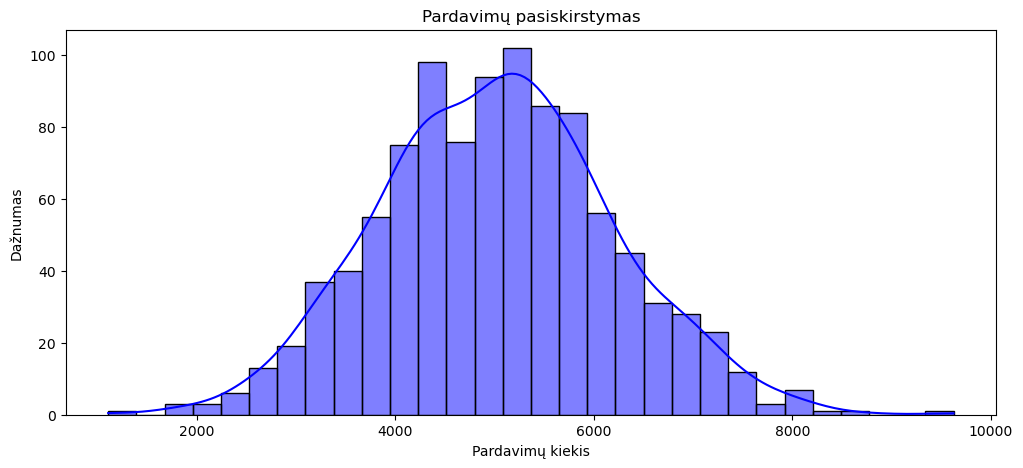

In [7]:
plt.figure(figsize=(12, 5))
sns.histplot(data["Pardavimai"], kde=True, bins=30, color="blue")
plt.title("Pardavimų pasiskirstymas")
plt.xlabel("Pardavimų kiekis")
plt.ylabel("Dažnumas")
plt.show()

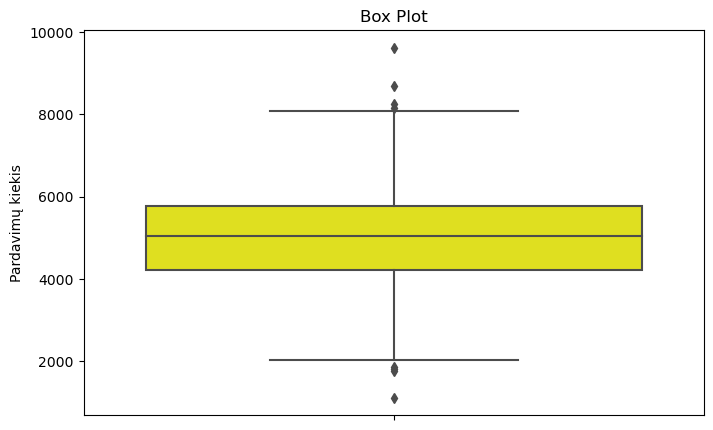

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=data["Pardavimai"], color="yellow")
plt.title("Box Plot")
plt.ylabel("Pardavimų kiekis")
plt.show()

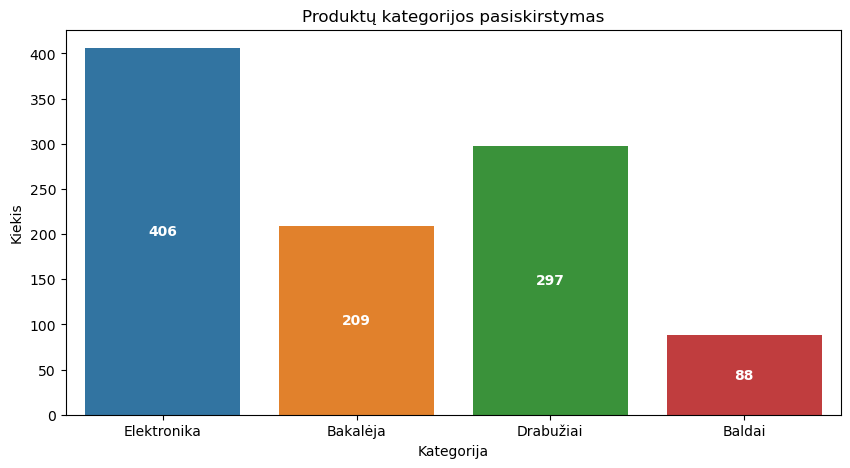

In [9]:
plt.figure(figsize=(10, 5))
ax=sns.countplot(x=data["Produktų_kategorija"])
ax.bar_label(ax.containers[0], fmt='%d', label_type='center', fontsize=10, color='white', fontweight='bold')
plt.title("Produktų kategorijos pasiskirstymas")
plt.xlabel("Kategorija")
plt.ylabel("Kiekis")
plt.show()


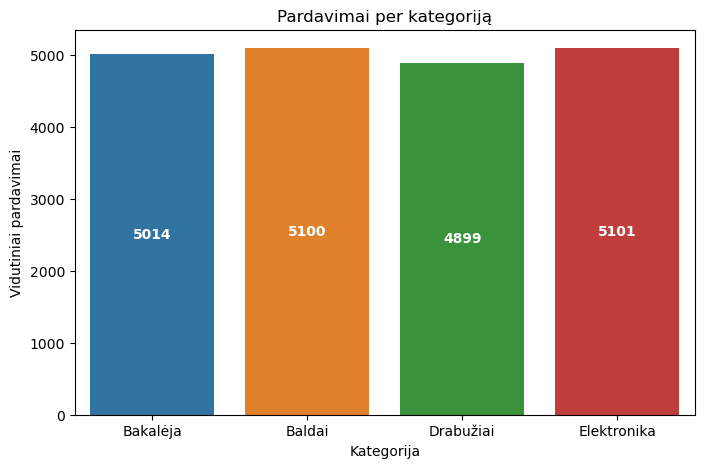

In [10]:
#Skaičiuojame vidutinius pardavimus per produktų kategoriją
sales = data.groupby("Produktų_kategorija")["Pardavimai"].mean()

plt.figure(figsize=(8, 5))
ax=sns.barplot(x=sales.index, y=sales.values)
ax.bar_label(ax.containers[0], fmt='%d', label_type='center', fontsize=10, color='white', fontweight='bold')
plt.title("Pardavimai per kategoriją")
plt.xlabel("Kategorija")
plt.ylabel("Vidutiniai pardavimai")
plt.show()

In [11]:
#Kodas patikrint nuokrypiams(outliers)

outliers_dict = {}

numeric = data.select_dtypes(include=np.number).columns

for col in numeric:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = (Q3 - Q1) * 1.5

    outliers = data[col][
        (data[col] < Q1 - IQR) | (data[col] > Q3 + IQR)
    ]
    if len(outliers) > 0:
        print(
            f"{col} turi {len(outliers)} nuokryp{'ius' if len(outliers) != 1 else 'į'}:"
        )
        for i, value in enumerate(outliers):
            if i == len(outliers) - 1:
                print(value, end="\n\n")
            else:
                print(value)
        outliers_dict[col] = outliers
    else:
        print(f"{col} neturi nuokrypių", end=".\n\n")

Pardavimai turi 8 nuokrypius:
1856.305875092307
8264.202999907542
9623.277788785665
1110.479191917113
8694.656970146285
1763.736028470114
1818.8362299283858
8158.858477804869

Klientų_amžius neturi nuokrypių.

Parduotuvės_reitingas neturi nuokrypių.

